**13/08/2026** -- Figure 6: Associations between deprivation and exposure to local and transported fire PM2.5 in African countries

Note that the figure being saved is for the 2000-2022 data.

In [22]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/ppca/share/proj")

In [23]:
library(dplyr)
library(readr)
library(tidyr)
library(stringr)
library(brms)
library(rstan)
library(cmdstanr)
library(sf)
library(ggplot2)
library(ggpattern)
library(patchwork)

In [24]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/data_prep.R"))
source(file.path(root, "src/deprivation_pm_bhm/pca.R"))
source(file.path(root, "src/deprivation_pm_bhm/model_setup.R"))
source(file.path(root, "src/deprivation_pm_bhm/model_summary.R"))
source(file.path(root, "src/deprivation_pm_bhm/postprocess.R"))
source(file.path(root, "src/deprivation_pm_bhm/plotting.R"))
source(file.path(root, "src/utils/utils.R"))

In [25]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
NAT_BOUNDS_PATH     <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "WB_countries_Admin0_10m")
western_sahara_path <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "western_sahara/gadm41_ESH_0.shp")

In [26]:
nat_bounds <- read_sf(NAT_BOUNDS_PATH)
esh_bounds <- read_sf(western_sahara_path)

In [27]:
# Function to post-process model
postprocess <- function(model, df, nat_bounds) {
    draws   <- as_draws_df(model)

    # PC1 effects in U & R (draws)
    pc1_draws_ur <- extract_pc1_draws_ur(draws)      
    
    # Posterior summary by country & U/R
    slopes_ur <- summarise_draws(
        pc1_draws_ur, 
        pivot = TRUE, pivot_cols = c("rural", "urban"),
        names_to = "urban_rural_cat",
        group_vars = c("country", "urban_rural_cat", "term")
    )
    
    # Post-stratification: p-w avg of U & R PC1 draws
    pc1_draws_pw_avg <- compute_pw_pc1_draws(pc1_draws_ur, df)
    
    # Posterior summary of U/R pooled effects draws
    slopes_pw_avg <- summarise_draws( 
        pc1_draws_pw_avg, 
        pivot = TRUE, pivot_cols = c("pooled"),
        names_to = "urban_rural_cat",
        group_vars = c("country", "urban_rural_cat", "term")
    )

    # Join to nat bounds
    sf_slopes_ur <- nat_bounds %>%
        select(WB_NAME, SUBREGION, geometry) %>%
        right_join( slopes_ur, by = c("WB_NAME" = "country") )

    sf_slopes_pw_avg <- nat_bounds |> 
        select(WB_NAME, SUBREGION, geometry) %>%
        right_join( slopes_pw_avg, by = c("WB_NAME" = "country") )

    list(
        "slopes_ur"     = slopes_ur,
        "slopes_pw_avg" = slopes_pw_avg,
        "sf_slopes_ur"  = sf_slopes_ur,
        "sf_slopes_pw_avg"  = sf_slopes_pw_avg,
        "pc1_draws_ur"  = pc1_draws_ur,
        "pc1_draws_pw_avg" = pc1_draws_pw_avg
    )
}

#### Models for 2000-2022:

In [28]:
# Prepare data
DATA_PATH   <- file.path(SCRATCH_DIR, 
                         "data/spatial/fire_pm_dep_paper_data",
                         "proc_data/df_af_annual_loc_tp_2000_2023.csv")

df <- read_csv(DATA_PATH) |> 
    filter(year <= 2022) |> 
    group_by(lon, lat) |>
    mutate(grid_id = cur_group_id()) |> # create grid_id for projecting SE vars
    ungroup()

df <- project_indicators(
    df, 
    list(edu_mean_years     = 2017,
         imp_san_access_pct = 2017,
         stunting_pct_u5    = 2017
    )
)

# Do PCA
pca_res <- compute_pca(
    df,
    method          = "ppca",
    se_indicators   = c("edu_mean_years", "imp_san_access_pct", "log_GDP_pc",
                        "child_dep_pct", "stunting_pct_u5"),
    n_pcs           = 5,
    scale           = TRUE,
    centre          = TRUE,
    seed            = 42,
    positive_vars   = c("child_dep_pct", "stunting_pct_u5"),
    negative_vars   = c("edu_mean_years", "imp_san_access_pct", "log_GDP_pc")
)

# Join PCs back onto df (helper funct)
df  <- prepare_analysis_data(df, 
                             pca_res$data, 
                             outcome = "fire_PM25_hu", # arbitrary, won't be used
                             scale_y = FALSE,
                             scale_PC1 = TRUE)

Rows: 994412 Columns: 107
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (96): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, fire_PM25_hu, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Projecting edu_mean_years forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0227167 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


[1] "Projecting imp_san_access_pct forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00349425 (tol = 0.002, component 1)”


[1] "Projecting stunting_pct_u5 forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0278442 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”
Warning message in pcaMethods::ppca(X, nPcs = n_pcs, seed = seed):
“stopped after max iterations, but rel_ch was > threshold”


In [29]:
path_loc <- file.path(
    SCRATCH_DIR, paste0(
        "data/spatial/deprivation_pm_bhm/",
        "original_model_hu_bc_attr_fire_PM25_emis_0_100km_scaleyFALSE_ppcaPcaMethod_5pcs",
        "_4chains_15000iter_5000warmup_24threads_normal10_betaPrior_cauchy_scalePrior.rds"
    )
)

path_tp <- file.path(
    SCRATCH_DIR, paste0(
        "data/spatial/deprivation_pm_bhm/",
        "original_model_hu_bc_attr_fire_PM25_emis_100_2000km_scaleyFALSE_ppcaPcaMethod_5pcs",
        "_4chains_12000iter_4000warmup_24threads_normal10_betaPrior_cauchy_scalePrior.rds"
    )
)

In [30]:
# Load models
model_loc <- readRDS(path_loc)
model_tp  <- readRDS(path_tp)

In [31]:
# Post-process models
slopes_model_loc    <- postprocess(model_loc, df, nat_bounds)
slopes_model_tp     <- postprocess(model_tp, df, nat_bounds)

Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”


##### Fig 6: maps of coefs:

In [32]:
options(repr.plot.height = 8, repr.plot.width = 12)

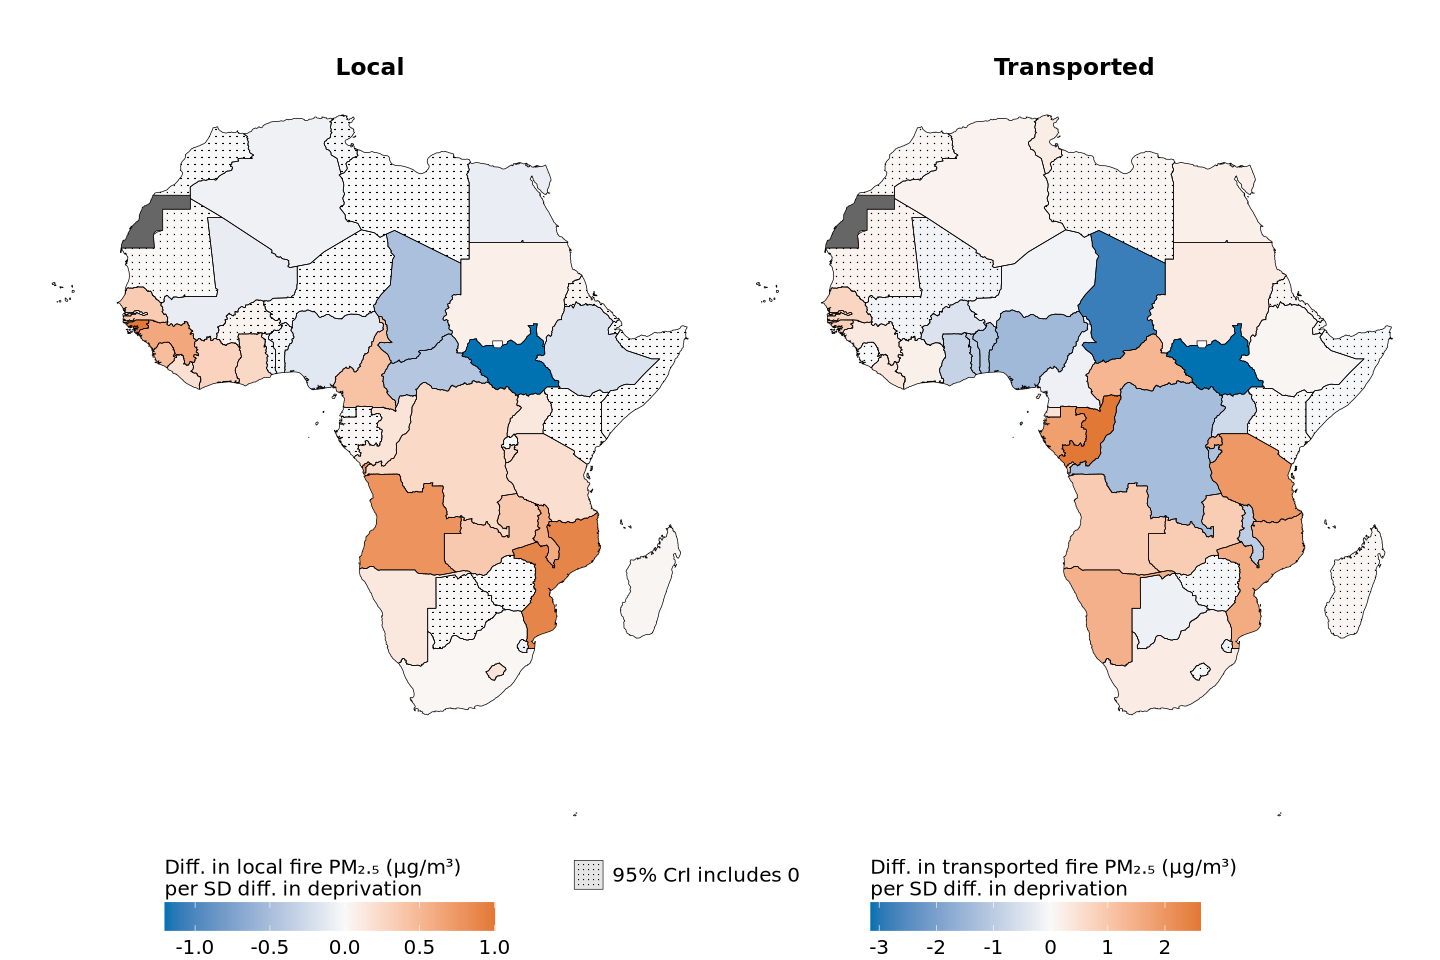

In [33]:
### Local
map_loc <- map_country_effects(
    slopes_model_loc$sf_slopes_pw_avg,
    fill_name = "Diff. in local fire PM₂.₅ (μg/m³)\nper SD diff. in deprivation",   #nolint
    pattern_name = NULL,
    urban_rural_var = NULL, # no facet variable
    # palette_low = "#b35806", 
    # palette_mid = "#F7F7F7",
    # palette_high = "#542788",
) + 
    labs(title = "Local") +
    guides(
        fill    = guide_colorbar(order = 1, barwidth = unit(7, "cm")),
        pattern = guide_legend(order = 2)
    ) +
    theme( 
        plot.title = element_text(size = 14, face = "bold", hjust = 0.5, margin = margin(t = 35)),  #nolint
        legend.position = "bottom",
        legend.title.position = "top",
        legend.key.spacing.x = unit(0.5, "cm"),
        legend.title = element_text(margin = margin(r = 25), size = 12, vjust = 1.1),   #nolint
        legend.text = element_text(color = "black", size = 12)
    ) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40")

### Transported
map_tp <- map_country_effects(
    slopes_model_tp$sf_slopes_pw_avg,
    fill_name = "Diff. in transported fire PM₂.₅ (μg/m³)\nper SD diff. in deprivation",   #nolint
    pattern_name = NULL,
    urban_rural_var = NULL, # no facet variable
    # palette_low = "#b35806", 
    # palette_mid = "#F7F7F7",
    # palette_high = "#542788",
) + 
    labs(title = "Transported") +
    guides(
        fill    = guide_colorbar(order = 1, barwidth = unit(7, "cm")),
        pattern = guide_legend(order = 2)
    ) +
    theme(
        plot.title = element_text(size = 14, face = "bold", hjust = 0.5, margin = margin(t = 35)),  #nolint
        legend.position = "bottom",
        legend.title.position = "top",
        legend.key.spacing.x = unit(0.5, "cm"),
        legend.title = element_text(margin = margin(r = 25), size = 12, vjust = 1.1),   #nolint
        legend.text = element_text(color = "black", size = 12)
    ) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40")

(map_loc | map_tp) +
    plot_layout(guides = "collect") &
    theme(
        legend.position = "bottom",
        legend.box.margin = margin(t = -8, b = 0),
        legend.margin = margin(t = 0, b = 0),
        legend.spacing.x = unit(1.5, "cm"),
        plot.margin = margin(0, 0, 0, 0, "mm")
    )

In [36]:
ggsave(
    filename = file.path(root, "paper_results/figures/fig_6.png"),
    height = 8,
    width = 12,
    bg = "white",
    dpi = 450
)

#### Models for 2000-2017:

In [14]:
# Prepare data
DATA_PATH   <- file.path(SCRATCH_DIR, 
                         "data/spatial/fire_pm_dep_paper_data",
                         "proc_data/df_af_annual_loc_tp.csv")

df <- read_csv(DATA_PATH) |> 
    filter(year <= 2017) |> 
    group_by(lon, lat) |>
    mutate(grid_id = cur_group_id()) |> # create grid_id for projecting SE vars (not needed here)
    ungroup()

# Do PCA
pca_res <- compute_pca(
    df,
    method          = "ppca",
    se_indicators   = c("edu_mean_years", "imp_san_access_pct", "log_GDP_pc",
                        "child_dep_pct", "stunting_pct_u5"),
    n_pcs           = 5,
    scale           = TRUE,
    centre          = TRUE,
    seed            = 42,
    positive_vars   = c("child_dep_pct", "stunting_pct_u5"),
    negative_vars   = c("edu_mean_years", "imp_san_access_pct", "log_GDP_pc")
)

# Join PCs back onto df (helper funct)
df  <- prepare_analysis_data(df, 
                             pca_res$data, 
                             outcome = "fire_PM25_hu", # arbitrary, won't be used
                             scale_y = FALSE,
                             scale_PC1 = TRUE)

Rows: 828600 Columns: 102
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (91): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, year, GDP_MD_E...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [15]:
path_loc <- file.path(
    SCRATCH_DIR, paste0(
        "data/spatial/deprivation_pm_bhm/",
        "original_model_hu_bc_attr_fire_PM25_emis_0_100km_scaleyFALSE_ppcaPcaMethod_5pcs_maxYear2017",
        "_4chains_15000iter_5000warmup_24threads_normal10_betaPrior_cauchy_scalePrior.rds"
    )
)

path_tp <- file.path(
    SCRATCH_DIR, paste0(
        "data/spatial/deprivation_pm_bhm/",
        "original_model_hu_bc_attr_fire_PM25_emis_100_2000km_scaleyFALSE_ppcaPcaMethod_5pcs_maxYear2017",
        "_4chains_15000iter_5000warmup_24threads_normal10_betaPrior_cauchy_scalePrior.rds"
    )
)

In [16]:
# Load models
model_loc <- readRDS(path_loc)
model_tp  <- readRDS(path_tp)

In [17]:
# Post-process models
slopes_model_loc    <- postprocess(model_loc, df, nat_bounds)
slopes_model_tp     <- postprocess(model_tp, df, nat_bounds)

Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”
Warning message:
“Dropping 'draws_df' class as required metadata was removed.”


##### Fig 6: maps of coefs:

In [18]:
options(repr.plot.height = 8, repr.plot.width = 12)

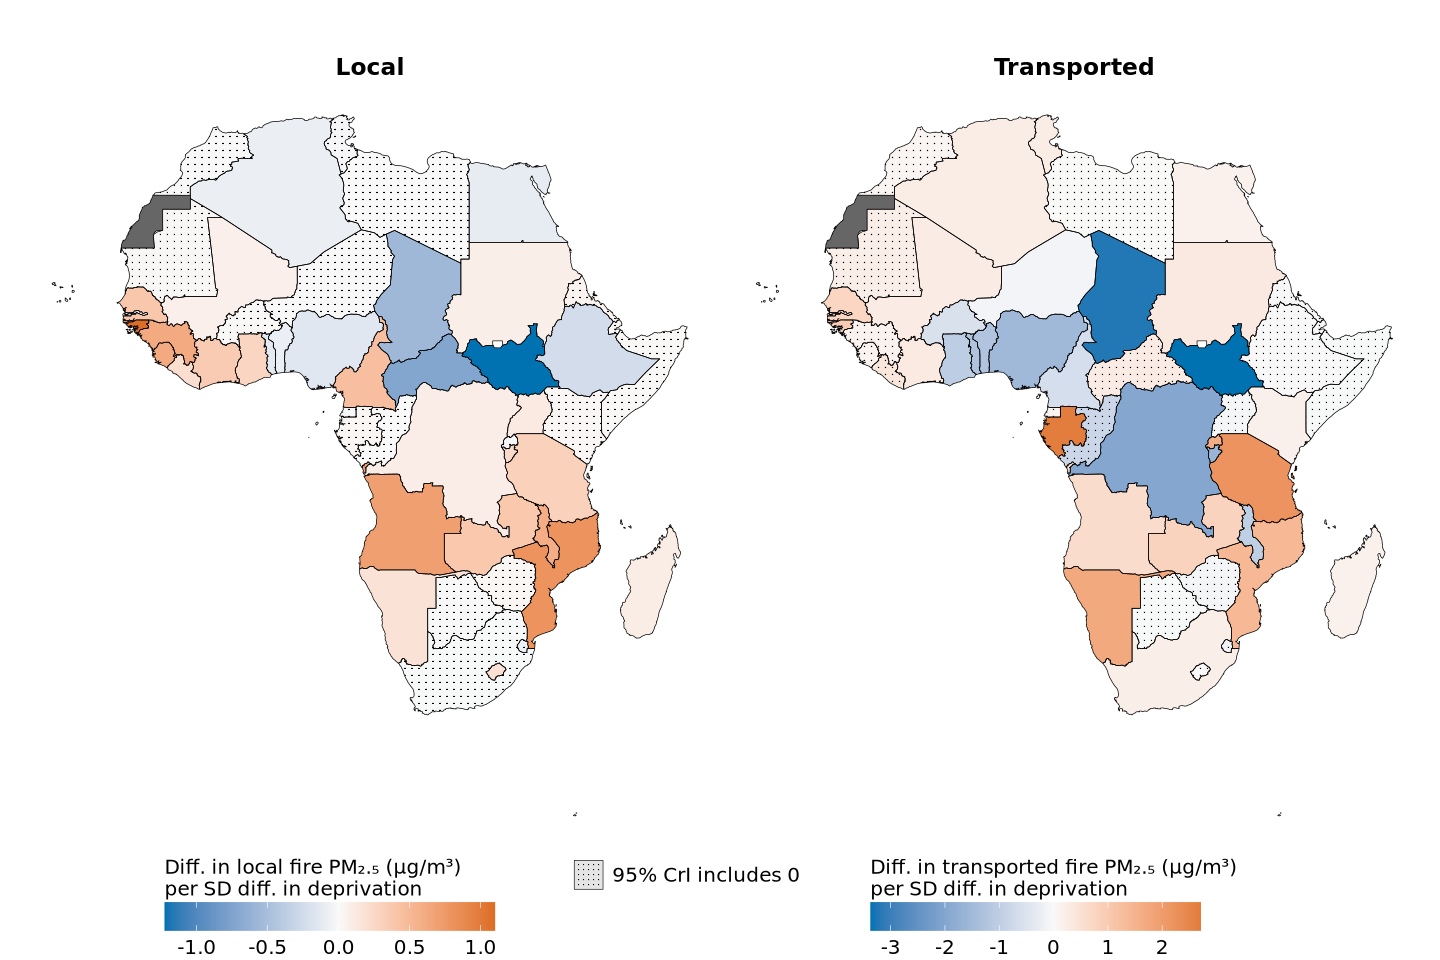

In [19]:
### Local
map_loc <- map_country_effects(
    slopes_model_loc$sf_slopes_pw_avg,
    fill_name = "Diff. in local fire PM₂.₅ (μg/m³)\nper SD diff. in deprivation",   #nolint
    pattern_name = NULL,
    urban_rural_var = NULL, # no facet variable
    # palette_low = "#b35806", 
    # palette_mid = "#F7F7F7",
    # palette_high = "#542788",
) + 
    labs(title = "Local") +
    guides(
        fill    = guide_colorbar(order = 1, barwidth = unit(7, "cm")),
        pattern = guide_legend(order = 2)
    ) +
    theme( 
        plot.title = element_text(size = 14, face = "bold", hjust = 0.5, margin = margin(t = 35)),  #nolint
        legend.position = "bottom",
        legend.title.position = "top",
        legend.key.spacing.x = unit(0.5, "cm"),
        legend.title = element_text(margin = margin(r = 25), size = 12, vjust = 1.1),   #nolint
        legend.text = element_text(color = "black", size = 12)
    ) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40")

### Transported
map_tp <- map_country_effects(
    slopes_model_tp$sf_slopes_pw_avg,
    fill_name = "Diff. in transported fire PM₂.₅ (μg/m³)\nper SD diff. in deprivation",   #nolint
    pattern_name = NULL,
    urban_rural_var = NULL, # no facet variable
    # palette_low = "#b35806", 
    # palette_mid = "#F7F7F7",
    # palette_high = "#542788",
) + 
    labs(title = "Transported") +
    guides(
        fill    = guide_colorbar(order = 1, barwidth = unit(7, "cm")),
        pattern = guide_legend(order = 2)
    ) +
    theme(
        plot.title = element_text(size = 14, face = "bold", hjust = 0.5, margin = margin(t = 35)),  #nolint
        legend.position = "bottom",
        legend.title.position = "top",
        legend.key.spacing.x = unit(0.5, "cm"),
        legend.title = element_text(margin = margin(r = 25), size = 12, vjust = 1.1),   #nolint
        legend.text = element_text(color = "black", size = 12)
    ) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40")

(map_loc | map_tp) +
    plot_layout(guides = "collect") &
    theme(
        legend.position = "bottom",
        legend.box.margin = margin(t = -8, b = 0),
        legend.margin = margin(t = 0, b = 0),
        legend.spacing.x = unit(1.5, "cm"),
        plot.margin = margin(0, 0, 0, 0, "mm")
    )

In [35]:
# ggsave(
#     plot = forestplot_fig,
#     filename = file.path(root, "paper_results/figures/fig_6.png"),
#     height = 8,
#     width = 12,
#     bg = "white",
#     dpi = 450
# )